<a href="https://colab.research.google.com/github/A01801224/TC3009C-RI/blob/main/Reto_Primer_Avance_Spaceship_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Después agregamos portada y demás pero por ahora hago este checklist de lo que proponemos poner y como vamos:

EDA (.shape, .info, .describe, .isnull().sum(), variable objetivo, .head(), .sample(), .tail(), .dtypes, .nunique() )

Datos nulos

Tipos de dato y cardinalidad

Variables categóricas ( .value_counts(), .groupby(), .mean() )

Tendencia central y dispersión

Skewness

Outliers-Regla de Tukey

Correlación

Tabla de contingencia ( pd.crosstab() )

Boxplots

Variables numéricas + interpretación de skewness

Matriz de correlación

# 1. CARGA Y COMPRENSIÓN DEL DATASET

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pega aquí el enlace Raw de tu archivo
url_test = "https://raw.githubusercontent.com/A01801224/TC3009C-RI/refs/heads/main/test.csv"
url_train = "https://raw.githubusercontent.com/A01801224/TC3009C-RI/refs/heads/main/train.csv"

# Pandas lee el archivo directamente desde GitHub
df_test = pd.read_csv(url_test)
df_train = pd.read_csv(url_train)


In [26]:
print(df_train.shape)
df_train.describe()
print("Target:", df_train["Transported"].dtype, df_train["Transported"].unique())

(8693, 14)
Target: bool [False  True]


Dado que Transported devuelve un valor booleano, estamos hablando de un problema de clasificación, debemos ser capaces de predecir False o True

# 2. EDA

In [27]:
#Revisión de train

df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [28]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [29]:
df_train.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [30]:
#Calculo de mean para que las columnas con valores binarios
(df_train.isnull().mean()*100).round(4).sort_values(ascending=False)

,0
CryoSleep,2.4963
ShoppingMall,2.3927
VIP,2.3352
HomePlanet,2.3122
Name,2.3007
Cabin,2.2892
VRDeck,2.1627
Spa,2.1051
FoodCourt,2.1051
Destination,2.0936


Al hacer el calculo de porcentaje de valores nulos por columna, observamos que casi todas las variables (a excepción ed PassengerId y Transported) presentan un porcentaje de datos faltante muy similar, entre 2.05% y 2.50%. No hay ninguna columna que destaque por encima de las demás

## Primer Acercamineto, Analisis y Clasificación de Variables

In [31]:
df_train.nunique()

,0
PassengerId,8693
HomePlanet,3
CryoSleep,2
Cabin,6560
Destination,3
Age,80
VIP,2
RoomService,1273
FoodCourt,1507
ShoppingMall,1115


Este primer acercamineto, analisis y clasificación de variables esta sujeto a cambios

**Categóricas** (baja cardinalidad, útiles para value_counts/groupby directo):
- HomePlanet
- CryoSleep
- Destination
- VIP
- Transported (variable objetivo)

**Numéricas continuas** (tiene sentido calcular media, mediana, dispersión):
- Age
- RoomService
- FoodCourt
- ShoppingMall
- Spa
- VRDeck

**Identificadores ** (no son categóricas ni numéricas puras tal como están):
- PassengerId → posible extracción de número de grupo
- Cabin → posible división en Deck, Number, Side
- Name → no aporta directamente al análisis en su forma actual

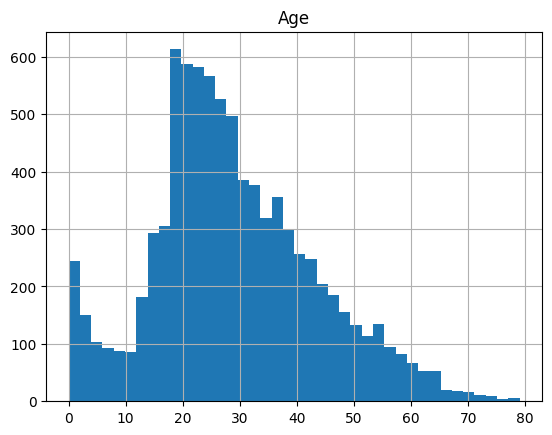

Age skew: 0.41909658301471536
Age outliers Tukey: 77


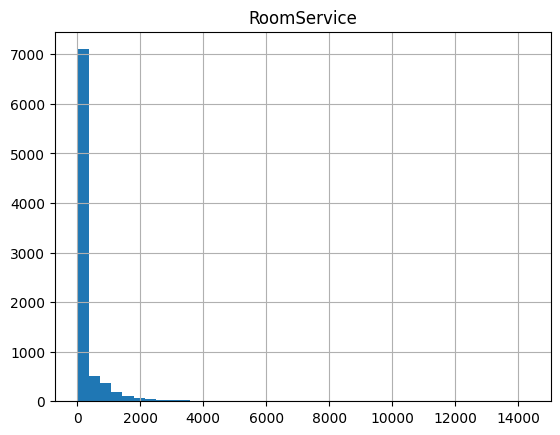

RoomService skew: 6.333014062092135
RoomService outliers Tukey: 1861


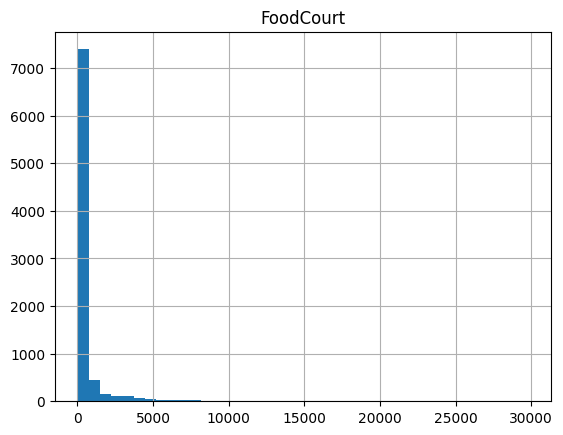

FoodCourt skew: 7.102227852514122
FoodCourt outliers Tukey: 1823


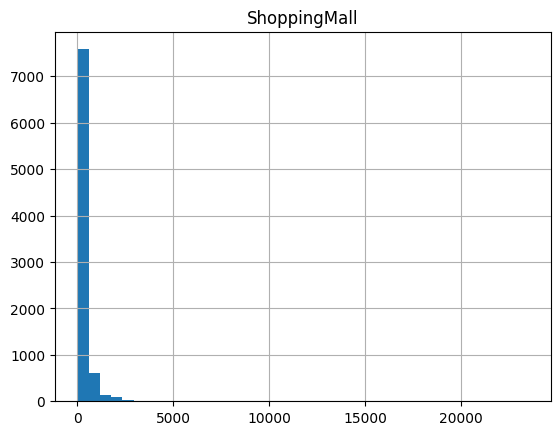

ShoppingMall skew: 12.62756203889759
ShoppingMall outliers Tukey: 1829


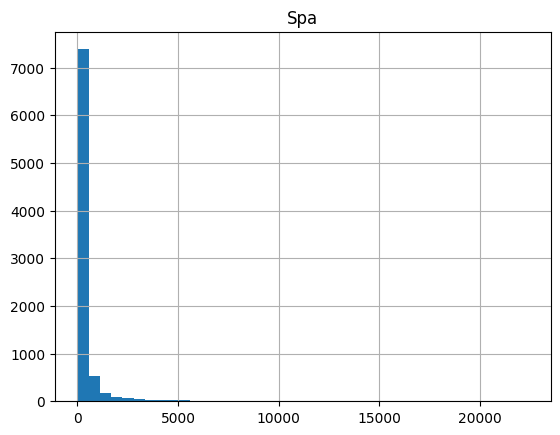

Spa skew: 7.63601988471242
Spa outliers Tukey: 1788


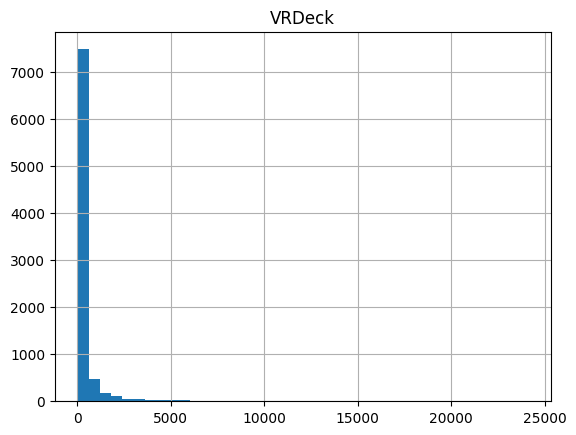

VRDeck skew: 7.819731592048683
VRDeck outliers Tukey: 1809


In [32]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
import matplotlib.pyplot as plt
num_cols = ["Age"] + spend_cols
for col in num_cols:
    df_train[col].hist(bins=40)
    plt.title(col)
    plt.show()
    print(col, "skew:", df_train[col].skew())
    q1, q3 = df_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = df_train[(df_train[col] < lower) | (df_train[col] > upper)]
    print(col, "outliers Tukey:", outliers.shape[0])

Al analizar la distribución de las variables numéricas encontramos dos comportamientos muy distintos. Age tiene un skewness de 0.42, lo que indica una distribución prácticamente simétrica, sin necesidad de transformación.

En cambio, las cinco variables de gasto (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck) presentan skewness muy alto (entre 6.3 y 12.6), con aproximadamente 1,800 valores marcados como outliers por la regla de Tukey en cada una (~21% de los registros)

In [33]:
cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
for col in cat_cols:
    print(col, df_train[col].value_counts(normalize=True, dropna=False)*100)

HomePlanet HomePlanet
Earth     52.939146
Europa    24.513977
Mars      20.234672
NaN        2.312205
Name: proportion, dtype: float64
CryoSleep CryoSleep
False    62.567583
True     34.936156
NaN       2.496261
Name: proportion, dtype: float64
Destination Destination
TRAPPIST-1e      68.043253
55 Cancri e      20.706315
PSO J318.5-22     9.156793
NaN               2.093639
Name: proportion, dtype: float64
VIP VIP
False    95.375590
NaN       2.335212
True      2.289198
Name: proportion, dtype: float64


Al revisar la cardinalidad y distribución de las variables categóricas encontramos niveles de desbalance muy distintos entre ellas. HomePlanet y Destination tienen una distribución razonablemente repartida entre sus categorías (Earth 53%/Europa 25%/Mars 20%, y TRAPPIST-1e 68%/55 Cancri e 21%/PSO J318.5-22 9%, respectivamente).

CryoSleep está más balanceada (63% False / 35% True). En cambio, VIP presenta un desbalance muy grande: 95.4% de los pasajeros no son VIP y solo 2.3% sí lo son, con un 2.3% adicional de nulos

Transported     False     True 
HomePlanet                     
Earth        0.576054  0.423946
Europa       0.341154  0.658846
Mars         0.476976  0.523024
Transported     False     True 
CryoSleep                      
False        0.671079  0.328921
True         0.182417  0.817583
Transported       False     True 
Destination                      
55 Cancri e    0.390000  0.610000
PSO J318.5-22  0.496231  0.503769
TRAPPIST-1e    0.528825  0.471175
Transported     False     True 
VIP                            
False        0.493668  0.506332
True         0.618090  0.381910


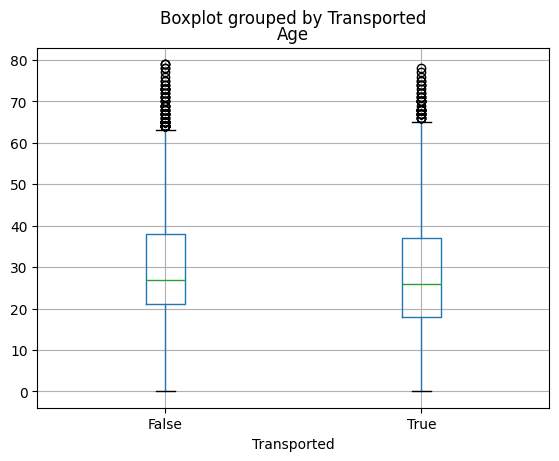

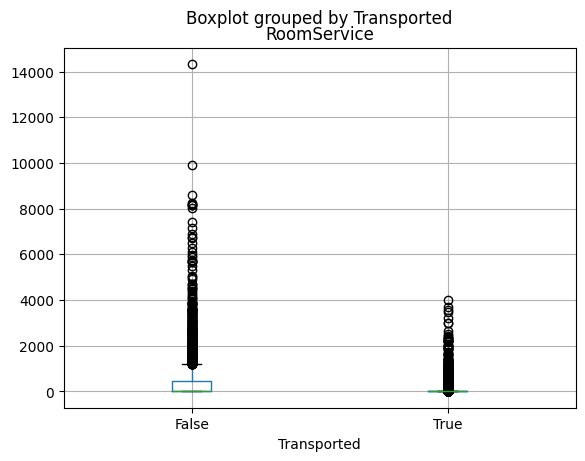

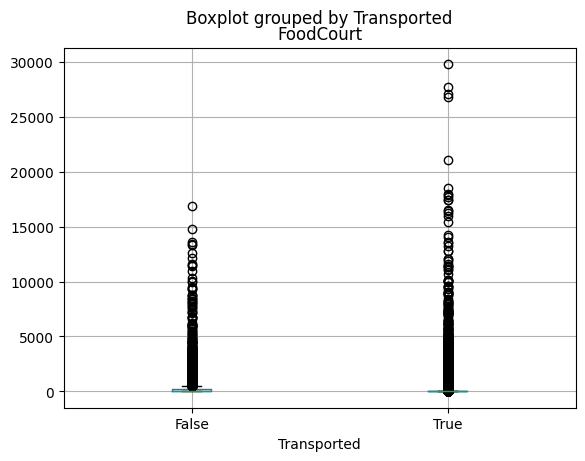

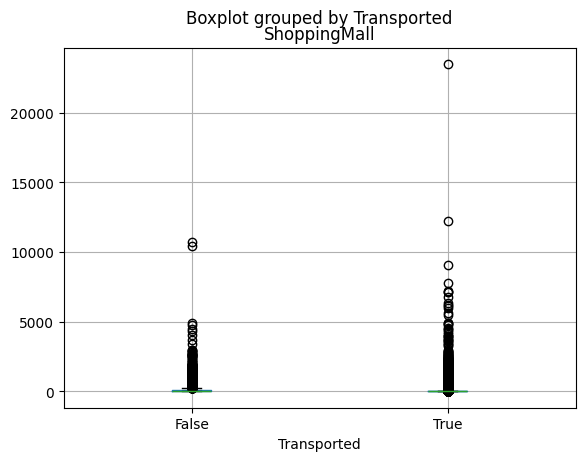

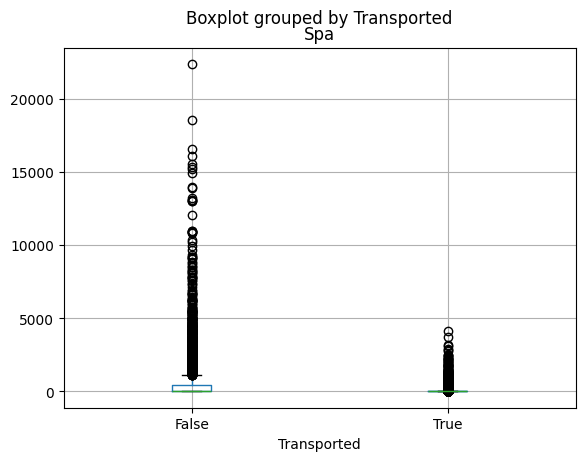

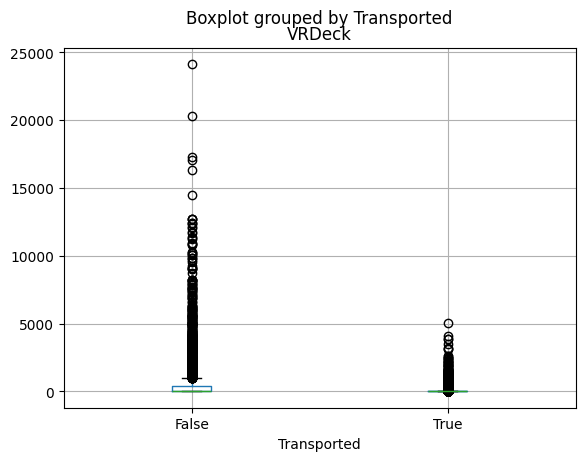

In [34]:
for col in cat_cols:
    print(pd.crosstab(df_train[col], df_train["Transported"], normalize="index"))

for col in num_cols:
    df_train.boxplot(column=col, by="Transported")
    plt.show()

In [35]:
# Dividir Cabin en Deck, Num, Side
df_train["Deck"] = df_train["Cabin"].str.split("/").str[0]
df_train["CabinNum"] = df_train["Cabin"].str.split("/").str[1]
df_train["Side"] = df_train["Cabin"].str.split("/").str[2]

print(df_train["Deck"].value_counts(dropna=False))
print(df_train["Side"].value_counts(dropna=False))

# Relación con el target
print(pd.crosstab(df_train["Deck"], df_train["Transported"], normalize="index"))
print(pd.crosstab(df_train["Side"], df_train["Transported"], normalize="index"))

Deck
F      2794
G      2559
E       876
B       779
C       747
D       478
A       256
NaN     199
T         5
Name: count, dtype: int64
Side
S      4288
P      4206
NaN     199
Name: count, dtype: int64
Transported     False     True 
Deck                           
A            0.503906  0.496094
B            0.265725  0.734275
C            0.319946  0.680054
D            0.566946  0.433054
E            0.642694  0.357306
F            0.560129  0.439871
G            0.483783  0.516217
T            0.800000  0.200000
Transported     False     True 
Side                           
P            0.548740  0.451260
S            0.444963  0.555037


Deck muestra relación clara con el target: B (73.4%) y C (68.0%) tienden a ser transportados, mientras E (35.7%) y F (44.0%) tienden a no serlo. T marca 80%/20% pero solo tiene 5 casos, así que no es confiable. Side también se relaciona, más ligero: S 55.5% vs P 45.1%. Ambas tienen 199 nulos (2.3%), igual que el resto del dataset.

### Clasificación de Valores Faltantes: Informativos vs. Reales

Para decidir la estrategia de imputación en el Paso 4, es indispensable entender el contexto del problema y cómo interactúan las variables entre sí. A partir de la descripción del dataset, podemos clasificar los nulos de la siguiente manera:

*   **Faltantes Informativos (Dependencia Lógica):** Las variables financieras (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) representan los gastos de los pasajeros. Según la lógica del viaje, los pasajeros que están en estado de animación suspendida (`CryoSleep == True`) están confinados a sus cabinas y no pueden consumir servicios. Por lo tanto, cualquier valor nulo en estas columnas para un pasajero dormido no es un dato perdido al azar, sino un **0 lógico**. De igual forma, si un pasajero tiene nulo en `CryoSleep` pero tiene gastos registrados mayores a cero, lógicamente sabemos que `CryoSleep == False`.
*   **Faltantes Reales (MCAR / MAR):** Variables como `Age`, `Destination`, `VIP`, `Cabin` y `HomePlanet` presentan nulos que parecen ser errores de registro o pérdida de información aleatoria[cite: 1]. Estos son faltantes reales. Para imputarlos, no podemos usar una deducción directa al 100%, sino que requeriremos estrategias estadísticas (como la mediana para `Age`) o inferencia relacional (como usar el `group_size` o el ID de grupo para deducir el `HomePlanet` o la cabina basándonos en los acompañantes del pasajero).

In [36]:
# Comprobación de la hipótesis de CryoSleep y Gastos
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

print("Gasto total de pasajeros en CryoSleep = True ")
print(df_train[df_train['CryoSleep'] == True][spend_cols].sum())

print("\nNulos en gastos para pasajeros en CryoSleep = True")
print(df_train[df_train['CryoSleep'] == True][spend_cols].isnull().sum())

print("\n Pasajeros con CryoSleep nulo, pero con gastos > 0")
gastos_totales = df_train[spend_cols].sum(axis=1)
cryo_nulo_con_gasto = df_train[(df_train['CryoSleep'].isnull()) & (gastos_totales > 0)]
print(f"Total de casos inferidos como CryoSleep = False: {cryo_nulo_con_gasto.shape[0]}")

Gasto total de pasajeros en CryoSleep = True 
RoomService     0.0
FoodCourt       0.0
ShoppingMall    0.0
Spa             0.0
VRDeck          0.0
dtype: float64

Nulos en gastos para pasajeros en CryoSleep = True
RoomService     68
FoodCourt       70
ShoppingMall    96
Spa             65
VRDeck          62
dtype: int64

 Pasajeros con CryoSleep nulo, pero con gastos > 0
Total de casos inferidos como CryoSleep = False: 119


**Analisis**

* Gasto total de pasajeros en CryoSleep = True: Los que suman 0 explica que ningún pasajero de este tipo gasto dinero en la nave
* Nulos en gastos CryoSleep = True: Los nulos explica la existencia de faltantes informativos, dado que los dormidos no gastan, podemos remplzara con 0s los nulos
* CryoSleep nulo, pero con gastos > 0: Son 119, y estos se innterpretan como un faltante real, dado que estaba despierto el pasajero y no gasto. Enotnces podemos dejar como False que estaba dormido

In [37]:
df_train["group"] = df_train["PassengerId"].str.split("_").str[0]
group_sizes = df_train["group"].value_counts()
df_train["group_size"] = df_train["group"].map(group_sizes)
print(pd.crosstab(df_train["group_size"], df_train["Transported"], normalize="index"))

Transported     False     True 
group_size                     
1            0.547555  0.452445
2            0.461950  0.538050
3            0.406863  0.593137
4            0.359223  0.640777
5            0.407547  0.592453
6            0.385057  0.614943
7            0.458874  0.541126
8            0.605769  0.394231


El tamaño de grupo también se relaciona con el target: viajar solo (55% de los pasajeros) se asocia con menor probabilidad de ser transportado (45.2%), mientras que los grupos medianos (3 a 6 personas) muestran las probabilidades más altas (59%-64%). En grupos muy grandes (7-8 personas) la tendencia se revierte, aunque con muestra reducida (solo 13 grupos de tamaño 8), por lo que ese extremo debe tomarse con cautela. Esto sugiere que crear una variable binaria como TraveledAlone podría capturar señal útil para el modelo.

## Analisis Especifico de Variables

**Revision Passenger**

Es importante mencionar que el formato de `PassengerId` es `gggg_pp`,
donde `gggg` es un identificador de grupo de 4 dígitos y `pp` es el número
de pasajero dentro de ese grupo (dos dígitos). Esta información proviene
del diccionario de datos de la competencia de Kaggle.

En este contexto, un grupo no necesariamente significa una familia, aunque
la mayoría de estos sí lo son. Esto es relevante porque nos permite explorar
si viajar en grupo (y no solo el vínculo familiar en sí) tiene alguna relación
con la probabilidad de haber sido transportado — por ejemplo, si los
integrantes de un mismo grupo tienden a compartir el mismo resultado en
`Transported`.

In [38]:
#Extraer el grpo de passengerid
df_train["group"] = df_train["PassengerId"].str.split("_").str[0]
print(df_train["group"])

0       0001
1       0002
2       0003
3       0003
4       0004
        ... 
8688    9276
8689    9278
8690    9279
8691    9280
8692    9280
Name: group, Length: 8693, dtype: object


Extraemos el identificador de grupo (`gggg`) de cada pasajero a partir de
`PassengerId`, dividiendo el valor por el separador `_` y quedándonos con
la primera parte. Los valores resultantes (0001, 0002, 0003...) corresponden
al grupo, no al número de pasajero dentro del grupo (`pp`).

In [39]:
group_sizes = df_train["group"].value_counts()
print(group_sizes)

group
9081    8
4005    8
8988    8
5133    8
4256    8
       ..
0022    1
0016    1
0015    1
0014    1
0012    1
Name: count, Length: 6217, dtype: int64


In [40]:
group_size_counts = group_sizes.value_counts().sort_index()
print(group_size_counts)

count
1    4805
2     841
3     340
4     103
5      53
6      29
7      33
8      13
Name: count, dtype: int64


Podemso observar que lso grupos más grandes son de 8 personas mientras que el mas pequeño es de solamente una. Con un total de 6217 grupos distintos entre los 8693 pasajeros totales.

También podemos observar que 4805 de esos grupos tienen un tamaño de 1, lo que siginifica que aproximadamnet el 55% de los pasajeros viajan sin acompáñante. El resto se distribuye en grupos cada vez más pequeños conforme aumenta el tamaño, desde 841 grupos de 2 personas hasta 13 grupos de 8 personas.  

**Revisión de HomePlanet**

In [41]:
df_train["HomePlanet"].unique()

array(['Europa', 'Earth', 'Mars', nan], dtype=object)

Home planet nos indica el planeta desde donde partió el pasajero, en este caso Europa, Earth y Mars. Podemos ver que hay valores nulos en esta columna

In [42]:
df_train["HomePlanet"].value_counts()

,count
HomePlanet,
Earth,4602
Europa,2131
Mars,1759


In [43]:
df_train["HomePlanet"].isnull().sum()

np.int64(201)

In [44]:
df_train["HomePlanet"].value_counts(normalize=True, dropna=False) * 100

,proportion
HomePlanet,
Earth,52.939146
Europa,24.513977
Mars,20.234672
NaN,2.312205


Podemos obseravr que al rededor del 53% de pasajeros vienen de la tierra, el 25% vienen de Europa, el 20% viene de Marte y el resto son valores nulos lo que quiere decir que es información que se perdió en el incidente

# 3. Selección y descarte de variables

**Variables a mantener:**
* HomePlanet, CryoSleep, Destination, Age y las de gasto continuo. Dado que su distribución es significativa
* Deck, Side, group_size se conservan dado que en EDA se mostro su relación con target

**Variables a descartar:**
* Name y PaseengerId dado que solo son identificadores sin valor predcitivo
* Cabin es redundante tras separar CabinNum, así que se eliminara
* VIP se elimina porque tiene un desbalance extremo

In [45]:
cols_to_drop = ['PassengerId', 'Name', 'Cabin', 'CabinNum', 'VIP']

df_train_selected = df_train.drop(columns=cols_to_drop)

print(df_train.shape)
print(df_train_selected.shape)
print(df_train_selected.columns.tolist())

(8693, 19)
(8693, 14)
['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Deck', 'Side', 'group', 'group_size']


# 4. Manejo de faltantes

A partir de la clasificación realizada en el Análisis Exploratorio, aplicaremos una estrategia de imputación mixta, lógica y estadística. Cada decisión se justifica de la siguiente manera:

*   **Imputación Lógica:**
    *   **`CryoSleep`:** Como demostramos previamente, si un pasajero registra gastos totales mayores a 0, inferimos con certeza que no está en animación suspendida. Se imputarán con `False`.
    *   **Variables Financieras (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`):** Si un pasajero está en `CryoSleep == True`, lógicamente no pudo consumir servicios. Estos faltantes informativos se imputarán con `0.0`.
*   **Imputación Estadística (Faltantes Reales):**
    *   **Numéricas (Gastos restantes y `Age`):** Se imputarán utilizando la **mediana**. Para las variables de gasto, la media sería un error debido a la presencia masiva de outliers detectados por la regla de Tukey y al sesgo positivo extremo, 0skewness > 6. Para `Age`, la mediana también otorga robustez frente a pasajeros de edad atípica.
    *   **Categóricas (`HomePlanet`, `Destination`, `Deck`, `Side`, y el resto de `CryoSleep`):** Al ser variables cualitativas, se imputarán utilizando la **moda** (el valor más frecuente de la distribución).

In [47]:
df_clean = df_train_selected.copy()
spend_cals = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"]